# **Notebook 4: Association Rules**

> **Objective:** Transform raw customer and basket datasets into clean datasets prepared for the next modelling stages. The **customer dataset** is cleaned and feature-engineered for **clustering**, while the **basket dataset** is preserved at transaction level for the generation of **association rules**.

---

## **Table of Contents**
1. [Imports and Libraries](#1-imports)
2. [Load Raw Datasets](#2-load)
3. [Customer Data Cleaning Pipeline](#3-customer-pipeline)
4. [Basket Data Preparation for Association Rules](#4-basket-association-rules)
5. [Validation Checks](#5-validation)
6. [Export Processed Data](#6-export)

---

## **1. Imports and Libraries**

In [1]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
from association import generate_rules


import geopandas as gpd
from mapclassify import classify

from association import generate_rules

pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)

In [2]:
basket_transaction_df = pd.read_pickle('../data/customer_basket_transactions.pkl')

basket_transaction_df.head()

,invoice_id,list_of_goods,customer_id,basket_size
0,3700630,"[chicken, rice, pepper, whole wheat rice, shrimp, toothpaste, gums, cereals, bluetooth headphones, vacuum cleaner, body spray]",12912,11
1,10242376,"[low fat yogurt, tomatoes, pepper, asparagus, mint green tea, phone charger, ground beef, tomato sauce, red wine, soup, energy bar, fresh bread]",22853,12
2,91550,"[cake, tomatoes, pancakes, iPad, final fantasy XIX, mineral water, ring light]",19,7
3,3137503,"[cereals, megaman zero, final fantasy XIX, honey]",10995,4
4,7165061,"[rice, frozen smoothie, black tea, tea, minecraft, almonds, fresh bread, milk]",27807,8


In [3]:
customer_clusters = pd.read_csv('../data/customer_clusters.csv')

customer_clusters.head()

,customer_id,cluster_kmeans_lifetime,cluster_name
0,3,4,Karens junior
1,4,6,Clean and green
2,5,0,Green screen
3,7,5,Large Families
4,8,5,Large Families


Merging

We used how='inner' because only costumer's baskets that have a cluster assigned make sense.

In [4]:
basket_with_clusters = pd.merge(basket_transaction_df, customer_clusters, on='customer_id', how='inner')

print(basket_with_clusters.shape)
basket_with_clusters.head()

(100000, 6)


,invoice_id,list_of_goods,customer_id,basket_size,cluster_kmeans_lifetime,cluster_name
0,3700630,"[chicken, rice, pepper, whole wheat rice, shrimp, toothpaste, gums, cereals, bluetooth headphones, vacuum cleaner, body spray]",12912,11,4,Karens junior
1,10242376,"[low fat yogurt, tomatoes, pepper, asparagus, mint green tea, phone charger, ground beef, tomato sauce, red wine, soup, energy bar, fresh bread]",22853,12,4,Karens junior
2,91550,"[cake, tomatoes, pancakes, iPad, final fantasy XIX, mineral water, ring light]",19,7,8,NaN
3,3137503,"[cereals, megaman zero, final fantasy XIX, honey]",10995,4,3,Average customer
4,7165061,"[rice, frozen smoothie, black tea, tea, minecraft, almonds, fresh bread, milk]",27807,8,3,Average customer


Use a transaction split to mine rules on one subset and validate whether those rules also hold in a holdout subset.

In [9]:
customers = basket_with_clusters[['customer_id', 'cluster_kmeans_lifetime']].drop_duplicates()


train_customers, test_customers = train_test_split(customers, test_size=0.20, random_state=42, stratify=customers['cluster_kmeans_lifetime'])

In [12]:
basket_with_clusters['cluster_kmeans_lifetime'].isna().sum() # we don't have any basket without cluster

np.int64(0)

In [13]:
train_baskets_df = basket_with_clusters[basket_with_clusters['customer_id'].isin(train_customers['customer_id'])].copy()

test_baskets_df = basket_with_clusters[basket_with_clusters['customer_id'].isin(test_customers['customer_id'])].copy()

This way, the same customer does not appear in both train and test set. This way we avoid leakage between sets.

In [14]:
train_baskets = list(train_baskets_df['list_of_goods'])
test_baskets = list(test_baskets_df['list_of_goods'])

In [15]:
print('We have {} rows in the train set.'.format(len(train_baskets)))
print('We have {} rows in the test set.'.format(len(test_baskets)))

We have 80078 rows in the train set.
We have 19922 rows in the test set.


## **Global Association Rules**

In this section, we mine association rules using the full training basket dataset, without separating customers by cluster. These global rules provide a baseline view of the most common product associations across the entire customer base.

The goal is to identify general purchasing patterns before moving to cluster-specific association rules, which will later support targeted promotion strategies for each customer segment.

**Note**: Before any association rules we first encode our data.

In [16]:
te = TransactionEncoder()
te_fit = te.fit(train_baskets).transform(train_baskets)
transactions_items_train = pd.DataFrame(te_fit, columns = te.columns_)

transactions_items_train.head()

,airpods,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,beer,black beer,black tea,blueberries,bluetooth headphones,body spray,bramble,brownies,burger sauce,burgers,butter,cake,candy bars,canned_tuna,carrots,cat food,catfish,cauliflower,cereals,champagne,chicken,chili,chocolate,chocolate bread,chutney,cider,cologne,cookies,cooking oil,corn,cottage cheese,cotton buds,cream,deodorant,dessert wine,dog food,eggplant,eggs,energy bar,energy drink,escalope,extra dark chocolate,...,pokemon scarlet,pokemon shield,pokemon sword,pokemon violet,portal,portal 2,protein bar,ratchet & clank,ratchet & clank 2,ratchet & clank 3,razor,red wine,rice,ring light,salad,salmon,salt,samsung galaxy 10,sandwich,seabass,shallot,shampoo,shower gel,shrimp,soda,soup,spaghetti,sparkling water,spinach,strawberries,strong cheese,tea,toilet paper,tomato juice,tomato sauce,tomatoes,tooth brush,toothpaste,trout,turkey,vacuum cleaner,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,Fal

### **Frequent Itemsets with Apriori algorithm**

Support measures how frequently an itemset appears in the transaction dataset.

In association rules, support is used to filter out very rare itemsets. A higher support means the itemset occurs more often and is therefore based on more evidence. In our case, we use a minimum support threshold of `0.02`, meaning that only itemsets appearing in at least **2% of the training baskets** are kept.

In [17]:
support_itemsets_train = apriori(transactions_items_train, min_support = 0.02, use_colnames=True)

support_itemsets_train.sort_values(by='support', ascending=False)

,support,itemsets
3,0.128887,frozenset({asparagus})
0,0.121044,frozenset({airpods})
56,0.099715,frozenset({fresh bread})
26,0.099028,frozenset({cereals})
18,0.095707,frozenset({butter})
...,...,...
164,0.024576,"frozenset({bluetooth headphones, airpods})"
169,0.022041,"frozenset({cereals, fresh bread})"
168,0.021317,"frozenset({eggs, cereals})"
167,0.020168,"frozenset({butter, fresh bread})"


As the item `aspargus` has a support of `0.128`, this means that asparagus appears in approximately **12.8% of all baskets** in the training set.

### **Association Rules**

In [18]:
rules_train = association_rules(support_itemsets_train, metric='confidence', min_threshold = 0.15)

rules_train.sort_values('lift', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({bluetooth headphones}),frozenset({airpods}),0.071980,0.121044,0.024576,0.341430,2.820695,1.0,0.015863,1.334642,0.695542,0.145897,0.250735,0.272231
1,frozenset({airpods}),frozenset({bluetooth headphones}),0.121044,0.071980,0.024576,0.203033,2.820695,1.0,0.015863,1.164440,0.734369,0.145897,0.141218,0.272231
2,frozenset({airpods}),frozenset({energy drink}),0.121044,0.074652,0.024763,0.204581,2.740450,1.0,0.015727,1.163346,0.722558,0.144871,0.140410,0.268148
3,frozenset({energy drink}),frozenset({airpods}),0.074652,0.121044,0.024763,0.331716,2.740450,1.0,0.015727,1.315243,0.686333,0.144871,0.239684,0.268148
9,frozenset({cereals}),frozenset({eggs}),0.099028,0.091573,0.021317,0.215259,2.350671,1.0,0.012248,1.157613,0.637744,0.125922,0.136153,0.224021
8,frozenset({eggs}),frozenset({cereals}),0.091573,0.099028,0.021317,0.232783,2.350671,1.0,0.012248,1.174338,0.632511,0.125922,0.148456,0.224021
11,frozenset({cereals}),frozenset({fresh bread}),0.099028,0.099715,0.022041,0.222573,2.232080,1.0,0.012166,1.158030,0.612658,0.124735,0.136465,0.221806
10,frozenset({fresh bread}),frozenset({cereals}),0.099715,0.099028,0.022041,0.221039,2.232080,1.0,0.012166,1.156633,0.613125,0.124735,0.135422,0.221806
5,frozenset({cereals}),frozenset({butter}),0.099028,0.095707,0.020143,0.203405,2.125293,1.0,0.010665,1.135198,0.587673,0.115371,0.119096,0.206935
4,frozenset({butter}),frozenset({cereals}),0.095707,0.099028,0.020143,0.210465,2.125293,1.0,0.010665,1.141141,0.585514,0.115371,0.123684,0.206935


Since frequent itemsets with two products are now being generated, we can derive association rules from them. For example, if the itemset `{eggs, cereals}` is frequent, the algorithm can generate rules such as `{eggs} → {cereals}` and `{cereals} → {eggs}`. These rules are then evaluated using metrics such as support, confidence and lift.

Also, as the lift values are well above 1, this means the items are bought together more often than when bought by random chance.

### **Global Rule Validation on the Test Set**

To check whether the global association patterns are stable, we compare the rules obtained from the training baskets with the rules obtained from the test baskets. This gives an initial indication of whether the strongest associations are consistent across different subsets of the data.

This validation is used as a preliminary robustness check before generating cluster-specific association rules.

In [19]:
train_data_rules = rules_train[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
train_data_rules.columns = ['antecedents', 'consequents', 'support_train', 'confidence_train', 'lift_train']

In [20]:
te = TransactionEncoder()
te_fit_test = te.fit(test_baskets).transform(test_baskets)
transactions_items_test = pd.DataFrame(te_fit_test, columns=te.columns_)

In [21]:
support_itemsets_test = apriori(transactions_items_test, min_support=0.02, use_colnames=True)

In [22]:
rules_test = association_rules(support_itemsets_test, metric="confidence", min_threshold=0.15)

In [23]:
test_data_rules = rules_test[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
test_data_rules.columns = ['antecedents', 'consequents', 'support_test', 'confidence_test', 'lift_test']

evaluation = train_data_rules.merge(test_data_rules, on=['antecedents','consequents'], how = 'inner')

In [24]:
evaluation.columns

Index(['antecedents', 'consequents', 'support_train', 'confidence_train',
       'lift_train', 'support_test', 'confidence_test', 'lift_test'],
      dtype='str')

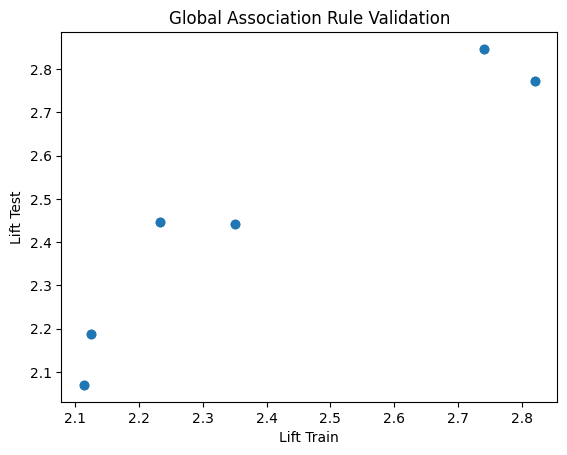

In [25]:
plt.scatter(
    evaluation['lift_train'],
    evaluation['lift_test'],
)

plt.xlabel('Lift Train')
plt.ylabel('Lift Test')
plt.title('Global Association Rule Validation')
plt.show()

In [26]:
print("Train rules:", len(rules_train))
print("Test rules:", len(rules_test))
print("Common rules:", len(evaluation))

Train rules: 12
Test rules: 20
Common rules: 12


In [27]:
evaluation[['support_train', 'support_test', 
            'confidence_train', 'confidence_test', 
            'lift_train', 'lift_test']].describe().round(3)

,support_train,support_test,confidence_train,confidence_test,lift_train,lift_test
count,12.000,12.000,12.000,12.000,12.000,12.000
mean,0.022,0.024,0.233,0.245,2.397,2.461
std,0.002,0.002,0.049,0.049,0.296,0.293
min,0.020,0.020,0.202,0.203,2.113,2.070
25%,0.020,0.022,0.204,0.217,2.125,2.188
50%,0.022,0.024,0.213,0.228,2.291,2.445
75%,0.025,0.026,0.225,0.248,2.740,2.773
max,0.025,0.027,0.341,0.350,2.821,2.847


We can calculate the % absolute difference between the values to have a metric on how well our train and test scenarios approximate:

In [28]:
mean_lift_perc_difference = (np.abs(evaluation['lift_train'] - evaluation['lift_test'])/evaluation['lift_train']).mean()

print(f"Mean absolute percentage difference in lift: {mean_lift_perc_difference:.2%}")

Mean absolute percentage difference in lift: 4.02%


## **Cluster-Specific Association Rules**

After validating the global association rules, we now generate association rules separately for each customer segment. This allows us to identify product associations that are more specific to each cluster and therefore more useful for targeted promotion strategies.

For each cluster, we filter the training baskets, encode the product lists, extract frequent itemsets with Apriori, and generate association rules using confidence and lift thresholds.

In [29]:
train_baskets_df.head()

,invoice_id,list_of_goods,customer_id,basket_size,cluster_kmeans_lifetime,cluster_name
0,3700630,"[chicken, rice, pepper, whole wheat rice, shrimp, toothpaste, gums, cereals, bluetooth headphones, vacuum cleaner, body spray]",12912,11,4,Karens junior
1,10242376,"[low fat yogurt, tomatoes, pepper, asparagus, mint green tea, phone charger, ground beef, tomato sauce, red wine, soup, energy bar, fresh bread]",22853,12,4,Karens junior
2,91550,"[cake, tomatoes, pancakes, iPad, final fantasy XIX, mineral water, ring light]",19,7,8,NaN
3,3137503,"[cereals, megaman zero, final fantasy XIX, honey]",10995,4,3,Average customer
4,7165061,"[rice, frozen smoothie, black tea, tea, minecraft, almonds, fresh bread, milk]",27807,8,3,Average customer


### **Cluster 0 - Older Long-Tenure Costumers**

In [4]:
generate_rules(cluster_0, 'cluster_kmeans_lifetime', min_support=0.02, min_confidence=0.15)

NameError: name 'cluster_0' is not defined

In [3]:
cluster_0 = train_baskets_df[train_baskets_df['cluster_kmeans_lifetime'] == 0]
transactions_items_train_0, support_itemsets_train_0, rules_train_0 = generate_rules(cluster_0, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_0)
display(rules_train_0)

NameError: name 'train_baskets_df' is not defined

In [35]:
cluster_1 = train_baskets_df[train_baskets_df['cluster_kmeans_lifetime'] == 1]
transactions_items_train_1, support_itemsets_train_1, rules_train_1 = generate_rules(cluster_1, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_1)
display(rules_train_1)

,support,itemsets
3,0.453678,frozenset({asparagus})
141,0.288374,frozenset({spinach})
148,0.286104,frozenset({tomatoes})
4,0.283530,frozenset({avocado})
127,0.277929,frozenset({salad})
...,...,...
341,0.020133,"frozenset({tomatoes, oil})"
368,0.020133,"frozenset({salad, avocado, antioxydant juice})"
486,0.020133,"frozenset({avocado, corn, tomatoes})"
511,0.020133,"frozenset({salad, eggplant, carrots})"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1196,"frozenset({spinach, mineral water})","frozenset({salad, asparagus})",0.062973,0.178777,0.022404,0.355769,1.990018,1.0,0.011146,1.274734,0.530926,0.102139,0.215523,0.240543
1194,"frozenset({salad, spinach})","frozenset({asparagus, mineral water})",0.112776,0.100363,0.022404,0.198658,1.979386,1.0,0.011085,1.122662,0.557687,0.117460,0.109260,0.210943
1197,"frozenset({asparagus, mineral water})","frozenset({salad, spinach})",0.100363,0.112776,0.022404,0.223228,1.979386,1.0,0.011085,1.142193,0.549992,0.117460,0.124491,0.210943
1213,"frozenset({salad, avocado})","frozenset({strawberries, asparagus})",0.111262,0.100515,0.022101,0.198639,1.976223,1.0,0.010918,1.122448,0.555827,0.116520,0.109090,0.209259
1216,"frozenset({strawberries, asparagus})","frozenset({salad, avocado})",0.100515,0.111262,0.022101,0.219880,1.976223,1.0,0.010918,1.139231,0.549186,0.116520,0.122215,0.209259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1300,frozenset({whole weat flour}),frozenset({avocado}),0.067363,0.283530,0.020739,0.307865,1.085829,1.0,0.001639,1.035159,0.084754,0.062815,0.033965,0.190505
657,frozenset({oil}),frozenset({asparagus}),0.061611,0.453678,0.029821,0.484029,1.066900,1.0,0.001870,1.058823,0.066822,0.061428,0.055555,0.274881
640,frozenset({cooking oil}),frozenset({asparagus}),0.063276,0.453678,0.030276,0.478469,1.054643,1.0,0.001569,1.047534,0.055312,0.062208,0.045377,0.272601
635,frozenset({whole weat flour}),frozenset({asparagus}),0.067363,0.453678,0.030730,0.456180,1.005513,1.0,0.000168,1.004600,0.005879,0.062674,0.004578,0.261957


In [38]:
cluster_2 = train_baskets_df[train_baskets_df['cluster_kmeans_lifetime'] == 2]
transactions_items_train_2, support_itemsets_train_2, rules_train_2 = generate_rules(cluster_2, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_2)
display(rules_train_2)

,support,itemsets
43,0.289881,frozenset({dog food})
5,0.282755,frozenset({babies food})
101,0.280950,frozenset({napkins})
36,0.277815,frozenset({cooking oil})
110,0.162945,frozenset({pet food})
...,...,...
311,0.020143,"frozenset({napkins, cooking oil, fresh bread})"
307,0.020143,"frozenset({dog food, napkins, cereals})"
302,0.020143,"frozenset({babies food, napkins, milk})"
290,0.020048,"frozenset({rice, toilet paper})"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
168,"frozenset({napkins, toilet paper})",frozenset({dog food}),0.054632,0.289881,0.023088,0.422609,1.457868,1.0,0.007251,1.229874,0.332217,0.071830,0.186909,0.251127
179,"frozenset({milk, cooking oil})",frozenset({babies food}),0.053492,0.282755,0.021378,0.399645,1.413394,1.0,0.006253,1.194700,0.309013,0.067894,0.162970,0.237625
191,"frozenset({dog food, chicken})",frozenset({napkins}),0.053397,0.280950,0.021188,0.396797,1.412340,1.0,0.006186,1.192053,0.308424,0.067658,0.161111,0.236106
167,"frozenset({dog food, napkins})",frozenset({toilet paper}),0.101283,0.161900,0.023088,0.227955,1.407997,1.0,0.006690,1.085558,0.322427,0.096161,0.078815,0.185280
196,"frozenset({babies food, cat food})",frozenset({cooking oil}),0.053682,0.277815,0.020998,0.391150,1.407954,1.0,0.006084,1.186147,0.306186,0.067625,0.156934,0.233366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,frozenset({pet food}),frozenset({milk}),0.162945,0.158860,0.027648,0.169679,1.068107,1.0,0.001763,1.013030,0.076177,0.093992,0.012863,0.171861
172,frozenset({ketchup}),frozenset({napkins}),0.074394,0.280950,0.022233,0.298851,1.063714,1.0,0.001332,1.025530,0.064712,0.066743,0.024895,0.188992
163,frozenset({asparagus}),frozenset({cooking oil}),0.081235,0.277815,0.023468,0.288889,1.039862,1.0,0.000900,1.015573,0.041723,0.069932,0.015334,0.186681
149,frozenset({butter}),frozenset({dog food}),0.091116,0.289881,0.026888,0.295099,1.018000,1.0,0.000475,1.007402,0.019454,0.075932,0.007348,0.193928


In [39]:
cluster_3 = train_baskets_df[train_baskets_df['cluster_kmeans_lifetime'] == 3]
transactions_items_train_3, support_itemsets_train_3, rules_train_3 = generate_rules(cluster_3, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_3)
display(rules_train_3)

,support,itemsets
24,0.375605,frozenset({cereals})
51,0.374872,frozenset({fresh bread})
16,0.373259,frozenset({butter})
43,0.364756,frozenset({eggs})
6,0.223134,frozenset({bacon})
...,...,...
249,0.020085,"frozenset({rice, fresh bread})"
182,0.020085,"frozenset({salad, butter})"
192,0.020085,"frozenset({ham, cereals})"
135,0.020085,"frozenset({tea, asparagus})"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
483,"frozenset({butter, fresh bread})",frozenset({whole weat flour}),0.149978,0.120070,0.023750,0.158358,1.318875,1.0,0.005742,1.045491,0.284437,0.096429,0.043512,0.178080
484,frozenset({whole weat flour}),"frozenset({butter, fresh bread})",0.120070,0.149978,0.023750,0.197802,1.318875,1.0,0.005742,1.059616,0.274770,0.096429,0.056262,0.178080
476,"frozenset({honey, fresh bread})",frozenset({tea}),0.088550,0.208034,0.024043,0.271523,1.305186,1.0,0.005622,1.087153,0.256543,0.088219,0.080167,0.193549
502,frozenset({salt}),frozenset({green tea}),0.149245,0.117725,0.022871,0.153242,1.301695,1.0,0.005301,1.041945,0.272430,0.093694,0.040256,0.173757
501,frozenset({green tea}),frozenset({salt}),0.117725,0.149245,0.022871,0.194271,1.301695,1.0,0.005301,1.055883,0.262697,0.093694,0.052925,0.173757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,frozenset({chocolate bread}),frozenset({bacon}),0.150711,0.223134,0.033280,0.220817,0.989615,1.0,-0.000349,0.997026,-0.012206,0.097718,-0.002983,0.184981
314,"frozenset({eggs, oatmeal})",frozenset({fresh bread}),0.086791,0.374872,0.032107,0.369932,0.986824,1.0,-0.000429,0.992161,-0.014410,0.074744,-0.007901,0.227790
528,"frozenset({salt, cereals})",frozenset({butter}),0.060842,0.373259,0.022284,0.366265,0.981262,1.0,-0.000426,0.988964,-0.019927,0.054112,-0.011159,0.212983
631,frozenset({mineral water}),frozenset({oatmeal}),0.096613,0.214045,0.020232,0.209408,0.978338,1.0,-0.000448,0.994135,-0.023923,0.069662,-0.005899,0.151964


In [40]:
cluster_4 = train_baskets_df[train_baskets_df['cluster_kmeans_lifetime'] == 4]
transactions_items_train_4, support_itemsets_train_4, rules_train_4 = generate_rules(cluster_4, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_4)
display(rules_train_4)

,support,itemsets
0,0.206756,frozenset({airpods})
12,0.115004,frozenset({bluetooth headphones})
80,0.108852,frozenset({laptop})
47,0.107288,frozenset({energy drink})
3,0.103639,frozenset({asparagus})
...,...,...
178,0.022208,"frozenset({bluetooth headphones, iphone 10})"
182,0.022000,"frozenset({bluetooth headphones, airpods, energy drink})"
180,0.021270,"frozenset({bluetooth headphones, protein bar})"
181,0.020540,"frozenset({laptop, energy drink})"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
24,"frozenset({bluetooth headphones, airpods})",frozenset({energy drink}),0.056824,0.107288,0.022000,0.387156,3.608564,1.0,0.015903,1.456671,0.766433,0.154806,0.313503,0.296105
28,frozenset({energy drink}),"frozenset({bluetooth headphones, airpods})",0.107288,0.056824,0.022000,0.205053,3.608564,1.0,0.015903,1.186465,0.809759,0.154806,0.157160,0.296105
27,frozenset({bluetooth headphones}),"frozenset({airpods, energy drink})",0.115004,0.053383,0.022000,0.191296,3.583446,1.0,0.015861,1.170536,0.814624,0.150285,0.145691,0.301703
26,"frozenset({airpods, energy drink})",frozenset({bluetooth headphones}),0.053383,0.115004,0.022000,0.412109,3.583446,1.0,0.015861,1.505376,0.761596,0.150285,0.335714,0.301703
25,"frozenset({bluetooth headphones, energy drink})",frozenset({airpods}),0.033365,0.206756,0.022000,0.659375,3.189141,1.0,0.015101,2.328789,0.710129,0.100860,0.570592,0.382890
8,frozenset({bluetooth headphones}),frozenset({energy drink}),0.115004,0.107288,0.033365,0.290118,2.704101,1.0,0.021026,1.257549,0.712084,0.176600,0.204803,0.300550
9,frozenset({energy drink}),frozenset({bluetooth headphones}),0.107288,0.115004,0.033365,0.310982,2.704101,1.0,0.021026,1.284431,0.705929,0.176600,0.221445,0.300550
2,frozenset({airpods}),frozenset({energy drink}),0.206756,0.107288,0.053383,0.258195,2.406555,1.0,0.031201,1.203431,0.736808,0.204800,0.169043,0.377883
3,frozenset({energy drink}),frozenset({airpods}),0.107288,0.206756,0.053383,0.497570,2.406555,1.0,0.031201,1.578816,0.654711,0.204800,0.366614,0.377883
0,frozenset({bluetooth headphones}),frozenset({airpods}),0.115004,0.206756,0.056824,0.494107,2.389803,1.0,0.033046,1.568007,0.657128,0.214482,0.362248,0.384472


In [41]:
cluster_5 = train_baskets_df[train_baskets_df['cluster_kmeans_lifetime'] == 5]
transactions_items_train_5, support_itemsets_train_5, rules_train_5 = generate_rules(cluster_5, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_5)
display(rules_train_5)

,support,itemsets
133,0.340875,frozenset({shampoo})
40,0.336979,frozenset({deodorant})
134,0.336230,frozenset({shower gel})
149,0.335631,frozenset({toothpaste})
148,0.334432,frozenset({tooth brush})
...,...,...
327,0.020228,"frozenset({almonds, tooth brush, body spray})"
610,0.020078,"frozenset({energy bar, tooth brush, toothpaste, deodorant})"
323,0.020078,"frozenset({almonds, toothpaste, antioxydant juice})"
598,0.020078,"frozenset({body spray, tooth brush, toothpaste, deodorant})"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
618,frozenset({bluetooth headphones}),frozenset({airpods}),0.068325,0.126910,0.033263,0.486842,3.836109,1.0,0.024592,1.701405,0.793538,0.205365,0.412251,0.374472
619,frozenset({airpods}),frozenset({bluetooth headphones}),0.126910,0.068325,0.033263,0.262102,3.836109,1.0,0.024592,1.262606,0.846785,0.205365,0.207987,0.374472
1499,frozenset({energy drink}),frozenset({bluetooth headphones}),0.086155,0.068325,0.020827,0.241739,3.538085,1.0,0.014941,1.228700,0.784992,0.155830,0.186132,0.273282
1498,frozenset({bluetooth headphones}),frozenset({energy drink}),0.068325,0.086155,0.020827,0.304825,3.538085,1.0,0.014941,1.314553,0.769969,0.155830,0.239285,0.273282
1414,frozenset({laptop}),frozenset({airpods}),0.048097,0.126910,0.021277,0.442368,3.485669,1.0,0.015173,1.565708,0.749143,0.138402,0.361311,0.305009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1318,frozenset({asparagus}),frozenset({shower gel}),0.066826,0.336230,0.021876,0.327354,0.973602,1.0,-0.000593,0.986805,-0.028235,0.057390,-0.013372,0.196208
1345,frozenset({asparagus}),frozenset({toothpaste}),0.066826,0.335631,0.021726,0.325112,0.968660,1.0,-0.000703,0.984414,-0.033509,0.057064,-0.015833,0.194922
792,frozenset({airpods}),frozenset({protein bar}),0.126910,0.228648,0.027869,0.219599,0.960420,1.0,-0.001149,0.988404,-0.045074,0.085048,-0.011733,0.170743
1366,frozenset({asparagus}),frozenset({shampoo}),0.066826,0.340875,0.021576,0.322870,0.947180,1.0,-0.001203,0.973410,-0.056389,0.055879,-0.027317,0.193083
